# 10 - HGAOEnKF reconstruction

Hybrid gain analog offline EnKF (Sun et al. 2024) and its evidence-ranked extension, run
through the same three lanes as the pixel 3DVar in notebook 07 so all of them are compared
row for row in notebook 09.

The method is the 3DVar update with a second covariance blended in. Instead of one
covariance built from every prior state, each analysis scores the whole archive against the
observations it is about to assimilate, keeps the best `k`, and builds a second covariance
from those. The two gains are summed at weight `hybrid_w`, and the background moves off
zero to the analog mean. `hybrid_w` is Sun et al.'s alpha: at 0 the analysis is their
AOEnKF-B, the analog mean updated by the static covariance alone; at 1 their AOEnKF, updated
by the analog covariance alone. The grid spans both endpoints, so the published ablation
ladder falls out of the sweep rather than needing separate runs. The identity the test suite
pins is Sun et al.'s own: an analog ensemble as large as the pool reproduces the static
analysis whatever the weight.

**Two selection rules run side by side**, differing only in the score the archive is ranked
by:

- `misfit` is the published rule: the R-weighted residual `(y - Hx)' R^-1 (y - Hx)`, which
  is the likelihood of a candidate being the truth.
- `evidence` ranks by the candidate's marginal likelihood
  `(y - Hx)' (c H B H' + R)^-1 (y - Hx)` instead. A candidate is not the truth but the
  centre of a background with covariance `B`, and the update that consumes the ensemble
  already carries that spread. At `c = 0` the two rules coincide, so `misfit` is a boundary
  case of `evidence` the same way AOEnKF-B is a boundary case of the blend.

Everything else is shared: the same observations, the same taper, the same `b_scale` sweep,
the same two tuned parameters.

Three things are held fixed rather than tuned here, each for a stated reason:

- **The taper** (localization / shrinkage / coupling) is inherited per lane from the 3DVar
  runs in notebook 07. It answers a spatial question about the static covariance that those
  grids already settled, and holding it fixed is what makes the comparison a comparison of
  estimators rather than of two differently regularized covariances.
- **The treatment of observation staleness** is `TEMPORAL_DEFLATE` on the trajectory and
  withholding lanes. Which treatment to use was settled on the 3DVar lanes; letting it vary
  alongside the analog parameters would reintroduce the confound that putting the
  correction in the observation layer removed. The PPE lane carries no treatment at all,
  since it borrows network geometry without its climate time.
- **The evidence scale `c`** is fixed at `EVIDENCE_SCALE`. It states which error model
  selection assumes rather than tuning one, so it stays out of the grid; the sweep near the
  end of this notebook reports how much it matters.
- **The analog pool** is the prior half on the two same-model lanes, so it is disjoint from
  every truth by construction. That split is the leakage guard: analog selection picks
  states that match the observations, and a truth sitting in the pool would be selected
  first every time.

Only `k` and `hybrid_w` are tuned, per rule, on each lane's own selection split.

In [1]:
%load_ext autoreload
%autoreload 2

# Cap BLAS threading before numpy loads, for the same reason notebook 07 does: the
# assimilation runs thousands of small eigendecompositions, a size where splitting each
# one across cores costs more than it saves. HGAOEnKF runs two per analysis rather than
# one, so the cap matters more here, not less.
import os

for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = "1"

import json
import shutil
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube
from paleoreco.assim.analog import ANALOG_EVIDENCE, ANALOG_MISFIT, EVIDENCE_SCALE
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.assim import experiments as ex

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
FIG = Path("../outputs/figures/10_hgaoenkf")
FIG.mkdir(parents=True, exist_ok=True)

# Which lanes this pass runs. Each clears only its own artefacts, so switching one off
# leaves the others on disk. The trajectory and ablation lanes inherit their (k, hybrid_w)
# from the PPE and withholding grids, so those need a run in this pass or already written.
RUN_PPE = True
RUN_TRAJECTORY = True
RUN_WITHHOLDING = True
RUN_ABLATIONS = True
RUN_EVIDENCE_SCALE = True

# The analog selection rules scored side by side. Every lane below runs each of them into
# its own directory, so the two never overwrite each other's artefacts.
RULES = (ANALOG_MISFIT, ANALOG_EVIDENCE)
RULE_LABEL = {ANALOG_MISFIT: "HGAOEnKF", ANALOG_EVIDENCE: "evidence-ranked HGAOEnKF"}
# Which of them this pass recomputes. A rule listed in RULES but not here is read back from
# its last run instead, so a rule already recorded on disk does not have to be recomputed
# to compare a new one against it. Everything downstream still sees both, because the
# selected (k, hybrid_w) comes from the config each lane wrote either way.
RUN_RULES = RULES

# The tuning grid. b_scale is swept inside every config, as it is for 3DVar.
K_GRID = ex.K_GRID
W_GRID = ex.HYBRID_W_GRID
# A priori config from Sun et al., scored alongside the tuned winner so the write-up can
# say whether the margin survives without tuning. Both are grid points, so it costs nothing.
K_APRIORI, W_APRIORI = 60, 0.5
# Background amplitudes the evidence rule is scored against. Zero is the misfit rule, so
# the curve reports the reduction as well as the sensitivity.
EVIDENCE_SCALE_GRID = (0.0, 1.0, 2.0, 5.0, 10.0, 20.0)

print(f"k grid {K_GRID}, hybrid_w grid {W_GRID} -> {len(K_GRID) * len(W_GRID)} configs")
print(f"selection rules {RULES}, evidence scale {EVIDENCE_SCALE}")

k grid (20, 40, 60, 100), hybrid_w grid (0.0, 0.25, 0.5, 0.75, 1.0) -> 20 configs
selection rules ('misfit', 'evidence'), evidence scale 1.0


## Prior cube, observations, and the inherited tapers

Each lane takes the taper its 3DVar counterpart selected in notebook 07, read from that
run's config. The withholding lane selects a different operating point from the two
same-model lanes; that divergence predates this notebook and is inherited rather than
resolved here.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))

D3 = OUT / "3dvar_pixel"
TAPER_KEYS = ["localization_km", "shrinkage_lambda", "alpha"]


def inherited_taper(config_name):
    """The taper the 3DVar run of one lane selected."""
    path = D3 / config_name
    if not path.exists():
        raise FileNotFoundError(
            f"{path} is missing. HGAOEnKF inherits its taper from the 3DVar lanes, so run "
            "notebook 07 first, or pass a taper to the grid drivers directly.")
    win = json.load(open(path))["selected"]
    return {k: win[k] for k in TAPER_KEYS}


TAPER_PPE = inherited_taper("ppe_config.json")
TAPER_WH = inherited_taper("withholding_random_config.json")
print(f"cube {cube.shape}, {len(ages)} ages, {long_ppe['site'].nunique()} sites")
print(f"PPE / trajectory taper : {TAPER_PPE}")
print(f"withholding taper      : {TAPER_WH}")

cube (804, 2, 32, 64), 804 ages, 187 sites
PPE / trajectory taper : {'localization_km': 15000.0, 'shrinkage_lambda': 0.0, 'alpha': 0.25}
withholding taper      : {'localization_km': None, 'shrinkage_lambda': 0.5, 'alpha': 0.75}


## Cost check

HGAOEnKF rebuilds a covariance per analysis, so its gain cannot be reused across
observation vectors the way a fixed-covariance one is: a static-B analysis factorizes once
per network and each observation vector costs a back-substitution, while this one
factorizes twice per observation vector. Measured per analysis, the square-root update over
the `b_scale` sweep dominates, and it is flop-bound rather than call-bound, so batching it
does not help. The whole analysis runs about four times a 3DVar one. The evidence rule adds
one product over the pool per analysis, against a covariance build two orders of magnitude
larger, so the two rules cost the same.

Measured on this machine with threads capped, one config per lane **per rule**:

| lane | per config | full grid, both rules |
| --- | --- | --- |
| PPE | ~60 s | ~25 min |
| trajectory | ~2 min | two runs |
| withholding | ~5-8 min | ~2-3 h |
| ablations | ~5-8 min each | ~50 min |
| evidence scale sweep | ~60 s each | ~6 min |

The withholding lane dominates. If that is too long, the lever is `K_GRID`: dropping to
`(40, 60)` halves it and still brackets the optimum the PPE lane finds, at the cost of not
being able to show a divergent one. The check below re-measures rather than trusting these
numbers, since they depend on the machine.

In [ ]:
COST_CHECK = False    # one config on each lane, to size the grid before committing to it

if COST_CHECK:
    tmp = OUT / "_cost_check"
    shutil.rmtree(tmp, ignore_errors=True)
    for rule in RUN_RULES:
        for lane, fn, obs, taper, kw in (
            ("ppe", ex.run_hgaoenkf_ppe_grid, long_ppe, TAPER_PPE,
             dict(n_noise=5, truth_stride=10)),
            ("withholding", ex.run_hgaoenkf_withholding_grid, long_wh, TAPER_WH,
             dict(k_folds=5)),
        ):
            t0 = time.time()
            fn(cube, ages, lats, lons, valid, obs, str(tmp / rule / lane),
               k_grid=(K_APRIORI,), hybrid_w_grid=(W_APRIORI,), selection=rule,
               **taper, **kw)
            # A one-point grid still runs the winner pass, so halve it for the per-config cost.
            per = (time.time() - t0) / 2
            print(f"{rule} / {lane}: {per:.0f}s per config -> "
                  f"{len(K_GRID) * len(W_GRID)} configs "
                  f"~ {(len(K_GRID) * len(W_GRID) + 1) * per / 60:.0f} min")
    shutil.rmtree(tmp, ignore_errors=True)
else:
    print("cost check off")

## PPE lane

Same-model pseudo-proxy experiment. The older half of the age axis builds the covariance
and supplies the analog pool; truths come from the younger half, so no candidate can be the
truth. Each truth borrows several real-proxy network shapes: `(k, hybrid_w, b_scale)` is
selected on the held-out shapes and reported on a disjoint one.

This is the lane the headline margin rests on. It carries no temporal treatment, which is
what keeps it directly comparable with the 3DVar PPE rows already on disk. Both rules run
here, each selecting its own `(k, hybrid_w)` on its own selection split, which is what makes
the head-to-head in notebook 09 a comparison at matched protocol rather than at a shared
operating point one of them never chose.

In [3]:
# Files each lane owns. The PPE and withholding lanes share one metrics CSV, as they do
# for 3DVar, so clearing has to be per lane rather than per directory. Each selection rule
# owns a directory, so the two passes cannot overwrite each other's npz or config.
RULE_DIR = {ANALOG_MISFIT: "hgaoenkf_pixel", ANALOG_EVIDENCE: "hgaoenkf_evidence_pixel"}
HG = {rule: OUT / name for rule, name in RULE_DIR.items()}
HG_TRAJ = {rule: OUT / f"{name}_trajectory" for rule, name in RULE_DIR.items()}
HG_ABL = OUT / "hgaoenkf_pixel_ablations"
HG_SCALE = OUT / "hgaoenkf_evidence_scale"

LANE_FILES = {
    "ppe": ("ppe_config.json", "ppe_analysis.npz", "ppe_skill_vs_distance.npz"),
    "withholding_random": ("withholding_random_config.json",
                           "withholding_random_predictions.npz"),
}


def clear_lane(directory, lane):
    """Drop one lane's artefacts and its rows from the appended metrics CSV."""
    for name in LANE_FILES[lane]:
        (directory / name).unlink(missing_ok=True)
    csv = directory / "metrics.csv"
    if not csv.exists():
        return
    rest = pd.read_csv(csv)
    rest = rest[rest["lane"] != lane]
    if len(rest):
        rest.to_csv(csv, index=False)
    else:
        csv.unlink()


def last_run(path, lane_flag, lane_name):
    """The config a lane wrote, or None if that lane has never run here.

    Switching a lane off reads its last run rather than re-running it, which only works
    once there is one; without this the read fails on a fresh checkout.
    """
    if path.exists():
        return json.load(open(path))
    if lane_flag:
        raise FileNotFoundError(f"{path} was expected after running the {lane_name} lane")
    print(f"[hgaoenkf] no previous {lane_name} run at {path}; produce one with "
          f"RUN_{lane_name.upper()} = True and the rule listed in RUN_RULES")
    return None


K_SEL, W_SEL = {}, {}
for rule in RULES:
    HG[rule].mkdir(parents=True, exist_ok=True)
    run_this = RUN_PPE and rule in RUN_RULES
    if run_this:
        clear_lane(HG[rule], "ppe")
        print(f"[{rule}] ppe analog grid")
        ex.run_hgaoenkf_ppe_grid(cube, ages, lats, lons, valid, long_ppe, str(HG[rule]),
                                 k_grid=K_GRID, hybrid_w_grid=W_GRID, selection=rule,
                                 n_noise=5, truth_stride=10, progress_every=10, **TAPER_PPE)
    else:
        print(f"[{rule}] ppe grid off; reading the last run")

    cfg = last_run(HG[rule] / "ppe_config.json", run_this, "ppe")
    if cfg is not None:
        K_SEL[rule], W_SEL[rule] = cfg["selected"]["analog_k"], cfg["selected"]["hybrid_w"]
        print(f"selected on PPE ({rule}): k={K_SEL[rule]}, hybrid_w={W_SEL[rule]}, "
              f"b_scale={cfg['selected']['b_scale']}")

[misfit] ppe analog grid
  analog-grid config 1/20 (5%, elapsed 30s, eta 566s)
  analog-grid config 2/20 (10%, elapsed 58s, eta 526s)
  analog-grid config 3/20 (15%, elapsed 96s, eta 542s)
  analog-grid config 4/20 (20%, elapsed 124s, eta 496s)
  analog-grid config 5/20 (25%, elapsed 151s, eta 452s)
  analog-grid config 6/20 (30%, elapsed 186s, eta 434s)
  analog-grid config 7/20 (35%, elapsed 221s, eta 410s)
  analog-grid config 8/20 (40%, elapsed 256s, eta 383s)
  analog-grid config 9/20 (45%, elapsed 290s, eta 355s)
  analog-grid config 10/20 (50%, elapsed 325s, eta 325s)
  analog-grid config 11/20 (55%, elapsed 370s, eta 302s)
  analog-grid config 12/20 (60%, elapsed 414s, eta 276s)
  analog-grid config 13/20 (65%, elapsed 459s, eta 247s)
  analog-grid config 14/20 (70%, elapsed 504s, eta 216s)
  analog-grid config 15/20 (75%, elapsed 548s, eta 183s)
  analog-grid config 16/20 (80%, elapsed 611s, eta 153s)
  analog-grid config 17/20 (85%, elapsed 678s, eta 120s)
  analog-grid confi

### The selection surface

Pooled RRMSE on the selection split against both knobs, each at its own best `b_scale`,
with the two rules overlaid so the gap is read off one axis. The surface spans the
published family: `hybrid_w = 0` is AOEnKF-B and `hybrid_w = 1` is AOEnKF, with 3DVar a
reference line from its own run rather than an endpoint of the blend. An interior optimum
reproduces Sun et al.'s result; an optimum at `hybrid_w = 0` says the flow-dependent
covariance earns nothing on this prior and the analog mean carries the whole margin, which
is a finding rather than a failure. A flat surface would mean the analog machinery is not
earning its place; a rule whose surface sits below the other everywhere is not winning at
one lucky operating point.

The amplitude panel sits beneath the error panel, read at the same `b_scale`. RRMSE is flat
near its optimum in the amplitude direction, so a reconstruction can be visibly too flat at
almost no cost in the metric being selected on; the pair is what catches that.

misfit: selection-split RRMSE at each (k, hybrid_w), minimised over b_scale:


hybrid_w,0.00,0.25,0.50,0.75,1.00
analog_k,,,,,
20.0,0.5399,0.5408,0.5469,0.5608,0.5882
40.0,0.5394,0.5378,0.5389,0.5470,0.5669
60.0,0.5396,0.5377,0.5367,0.5433,0.5593
100.0,0.5410,0.5398,0.5378,0.5434,0.5555


evidence: selection-split RRMSE at each (k, hybrid_w), minimised over b_scale:


hybrid_w,0.00,0.25,0.50,0.75,1.00
analog_k,,,,,
20.0,0.5439,0.5361,0.5282,0.5290,0.5389
40.0,0.5436,0.5348,0.5260,0.5242,0.5306
60.0,0.5440,0.5347,0.5269,0.5240,0.5281
100.0,0.5455,0.5358,0.5288,0.5243,0.5253


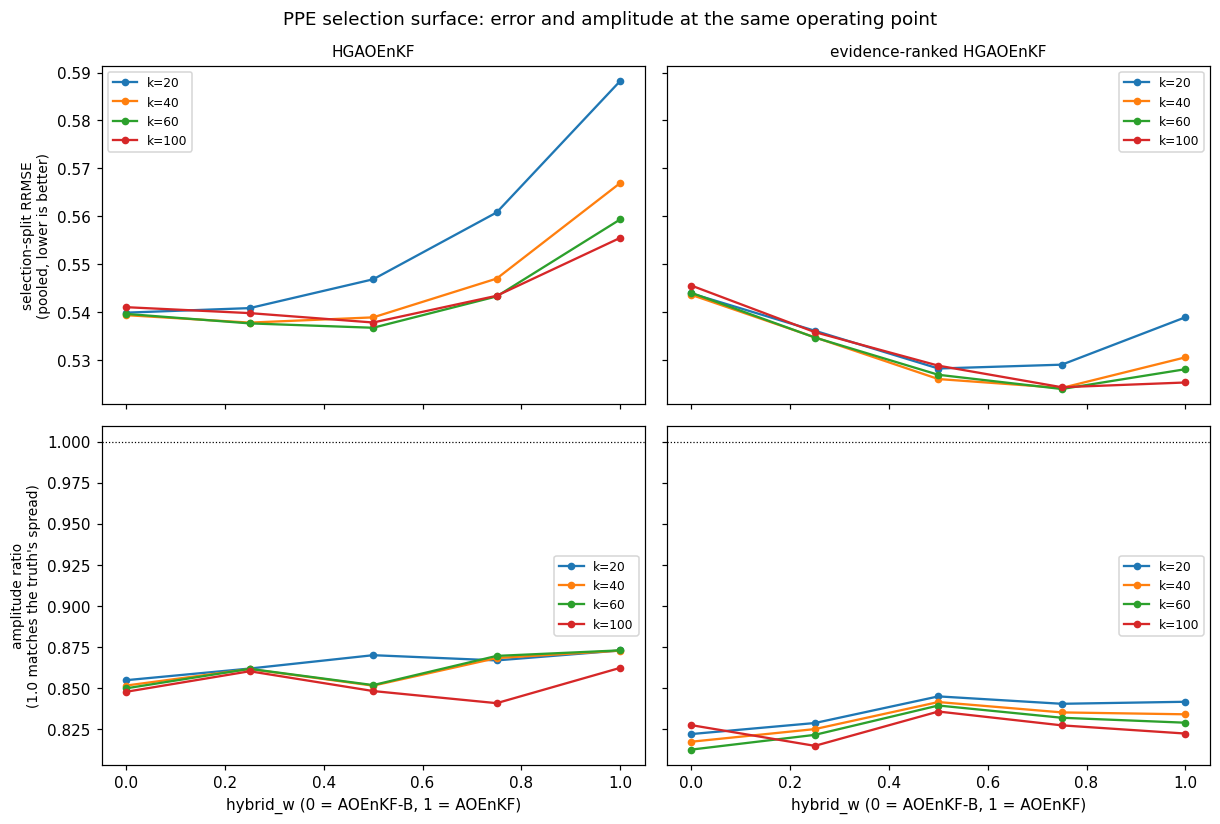

In [4]:
def ppe_surface(rule, metric="rrmse"):
    """Selection-split ``metric`` at each (k, hybrid_w), read at the RRMSE-optimal b_scale.

    Amplitude is read at the operating point RRMSE picks rather than optimised on its own:
    the pair is what says whether a low error was bought by flattening the field.
    """
    m = pd.read_csv(HG[rule] / "metrics.csv")
    label = ex.method_label(ex.hgaoenkf_estimator(rule))
    sel = m[(m.lane == "ppe") & (m.split == "selection") & (m.method == label)
            & (m.channel == "pooled") & (m.do_event == "all")]
    rrmse = sel[sel.metric == "rrmse"]
    best = rrmse.loc[rrmse.groupby(["analog_k", "hybrid_w"])["value"].idxmin(),
                     ["analog_k", "hybrid_w", "b_scale"]]
    at_best = sel[sel.metric == metric].merge(best, on=["analog_k", "hybrid_w", "b_scale"])
    return at_best.set_index(["analog_k", "hybrid_w"])["value"].unstack()


have = [rule for rule in RULES if (HG[rule] / "metrics.csv").exists()]
if len(have) < len(RULES):
    print(f"no PPE rows for {set(RULES) - set(have)}; run those rules to compare them")

# Error and amplitude at the same operating point, so a flat reconstruction cannot hide
# behind an RRMSE that barely moves with it.
PANELS = (("rrmse", "selection-split RRMSE\n(pooled, lower is better)"),
          ("amplitude", "amplitude ratio\n(1.0 matches the truth's spread)"))

fig, axes = plt.subplots(len(PANELS), len(have), squeeze=False, sharex=True, sharey="row",
                         figsize=(5.6 * len(have), 3.8 * len(PANELS)))
for row, (metric, ylabel) in enumerate(PANELS):
    for col, rule in enumerate(have):
        ax = axes[row, col]
        surface = ppe_surface(rule, metric)
        if metric == "rrmse":
            print(f"{rule}: selection-split RRMSE at each (k, hybrid_w), "
                  "minimised over b_scale:")
            display(surface.round(4))
        for k, values in surface.iterrows():
            ax.plot(values.index, values.values, marker="o", ms=4, label=f"k={int(k)}")
        if metric == "amplitude":
            ax.axhline(1.0, color="k", lw=0.8, ls=":")
            ax.set_xlabel("hybrid_w (0 = AOEnKF-B, 1 = AOEnKF)")
        else:
            ax.set_title(RULE_LABEL[rule], fontsize=10)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.legend(fontsize=8)
fig.suptitle("PPE selection surface: error and amplitude at the same operating point")
fig.tight_layout()
fig.savefig(FIG / "ppe_selection_surface.png", bbox_inches="tight")
plt.show()

## Trajectory lane

Every state of the younger half reconstructed in sequence with the real network at each
age, so the analyses form a time series and skill can be resolved by timescale. Each rule
inherits the PPE taper and its own PPE-selected `(k, hybrid_w)`, and sweeps `b_scale` alone.

The lane also records which prior states each analysis drew on. Analog selection is
discrete, so the chosen set turns over between neighbouring ages and both the prior mean
and the covariance jump with it. That is a high-frequency source a fixed-covariance
analysis does not have, and it is the thing to look at first if the fastest bands come out
worse than 3DVar's.

In [5]:
from paleoreco.assim.hgaoenkf import make_hgaoenkf
from paleoreco.assim.observations import TEMPORAL_DEFLATE

traj_cfg = {}
for rule in RULES:
    run_this = RUN_TRAJECTORY and rule in RUN_RULES
    if run_this and rule not in K_SEL:
        raise RuntimeError(f"the trajectory lane runs at {rule}'s PPE-selected "
                           "(k, hybrid_w); run its PPE grid first")
    if run_this:
        shutil.rmtree(HG_TRAJ[rule], ignore_errors=True)
        print(f"[{rule}] trajectory at k={K_SEL[rule]}, hybrid_w={W_SEL[rule]}")
        ex.run_trajectory(
            cube, ages, lats, lons, valid, long_ppe, str(HG_TRAJ[rule]),
            make_method=make_hgaoenkf(cube, ages, lats, lons, k=K_SEL[rule],
                                      hybrid_w=W_SEL[rule], selection=rule),
            estimator=ex.hgaoenkf_estimator(rule),
            method_cols=ex.analog_cols(K_SEL[rule], W_SEL[rule]),
            temporal_modes=(TEMPORAL_DEFLATE,), progress_every=50, **TAPER_PPE)
    else:
        print(f"[{rule}] trajectory lane off; reading the last run")

    cfg = last_run(HG_TRAJ[rule] / "trajectory_config.json", run_this, "trajectory")
    if cfg is not None:
        traj_cfg[rule] = cfg
        print(f"  scored {cfg['n_covered_ages']} ages, skipped {cfg['n_skipped_ages']}")
        print(f"  selection {cfg['selection_ages']} yr BP, test {cfg['test_ages']} yr BP")
        print("  b_scale* per method:", cfg["selected_b_scale_by_method"])

[misfit] trajectory at k=60, hybrid_w=0.5
  trajectory age 87/402 (22%, elapsed 6s, eta 22s)
  trajectory age 137/402 (34%, elapsed 15s, eta 29s)
  trajectory age 187/402 (47%, elapsed 21s, eta 24s)
  trajectory age 237/402 (59%, elapsed 27s, eta 18s)
  trajectory age 287/402 (71%, elapsed 33s, eta 13s)
  trajectory age 337/402 (84%, elapsed 39s, eta 7s)
  trajectory age 387/402 (96%, elapsed 44s, eta 2s)
  scored 365 ages, skipped 37
  selection [30025, 34550] yr BP, test [34575, 39125] yr BP
  b_scale* per method: {'hgaoenkf_temporal_deflate': 0.3}
[evidence] trajectory at k=60, hybrid_w=0.75
  trajectory age 87/402 (22%, elapsed 6s, eta 21s)
  trajectory age 137/402 (34%, elapsed 14s, eta 28s)
  trajectory age 187/402 (47%, elapsed 21s, eta 24s)
  trajectory age 237/402 (59%, elapsed 26s, eta 18s)
  trajectory age 287/402 (71%, elapsed 32s, eta 13s)
  trajectory age 337/402 (84%, elapsed 38s, eta 7s)
  trajectory age 387/402 (96%, elapsed 44s, eta 2s)
  scored 365 ages, skipped 37
 

misfit: analog-set overlap between neighbouring analyses (25 yr apart):
  mean 0.639, median 0.650, 10th pct 0.322
  fraction of adjacent pairs sharing under half their members: 0.242
  overlap beyond 1000 yr: 0.128 (chance = 0.149)
evidence: analog-set overlap between neighbouring analyses (25 yr apart):
  mean 0.451, median 0.433, 10th pct 0.200
  fraction of adjacent pairs sharing under half their members: 0.585
  overlap beyond 1000 yr: 0.125 (chance = 0.149)


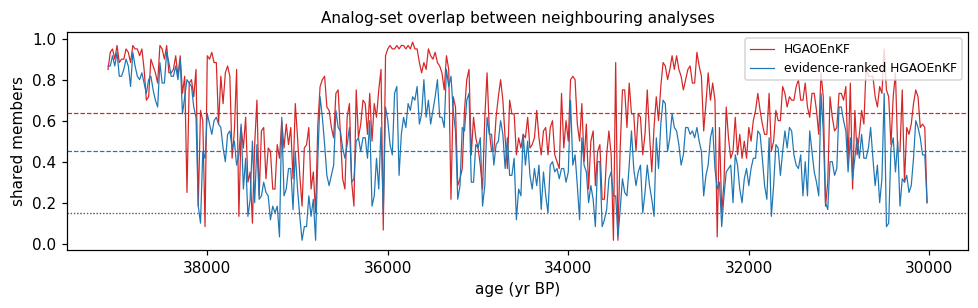


Overlap at chance for distant ages means selection carries real information about the epoch. Turnover between neighbours is what can inject variance into the fastest bands, so read this next to the band table in notebook 09.


In [6]:
if not traj_cfg:
    raise RuntimeError("no trajectory run to read")

fig, ax = plt.subplots(figsize=(9, 2.9))
for rule, colour in zip(traj_cfg, ("C3", "C0")):
    zt = np.load(HG_TRAJ[rule] / "trajectory_analysis.npz")
    idx = zt["analog_index"]
    step_yr = float(zt["step_yr"])
    sets = [set(row.tolist()) for row in idx]
    k = idx.shape[1]
    chance = k / traj_cfg[rule]["prior_meta"]["n_prior_ages"]

    adjacent = np.array([len(sets[i] & sets[i + 1]) / k for i in range(len(sets) - 1)])
    far = np.array([len(sets[i] & sets[j]) / k
                    for i in range(0, len(sets), 17) for j in range(0, len(sets), 19)
                    if abs(i - j) * step_yr > 1000])

    print(f"{rule}: analog-set overlap between neighbouring analyses "
          f"({step_yr:.0f} yr apart):")
    print(f"  mean {adjacent.mean():.3f}, median {np.median(adjacent):.3f}, "
          f"10th pct {np.percentile(adjacent, 10):.3f}")
    print(f"  fraction of adjacent pairs sharing under half their members: "
          f"{np.mean(adjacent < 0.5):.3f}")
    print(f"  overlap beyond 1000 yr: {far.mean():.3f} (chance = {chance:.3f})")

    ax.plot(zt["ages"][:-1], adjacent, lw=0.8, color=colour, label=RULE_LABEL[rule])
    ax.axhline(adjacent.mean(), color=colour, lw=0.8, ls="--")
    # k can differ between rules, so each carries its own chance level.
    ax.axhline(chance, color=colour, lw=0.8, ls=":")
ax.set_xlabel("age (yr BP)"); ax.set_ylabel("shared members")
ax.set_title("Analog-set overlap between neighbouring analyses", fontsize=10)
ax.invert_xaxis(); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "analog_set_stability.png", bbox_inches="tight")
plt.show()

print("\nOverlap at chance for distant ages means selection carries real information "
      "about the epoch. Turnover between neighbours is what can inject variance into "
      "the fastest bands, so read this next to the band table in notebook 09.")

## Withholding lane

Nested cross-validation over proxy sites: the only lane whose truth is real pollen rather
than a model state. Each rule picks its own `(k, hybrid_w)` here rather than inheriting the
PPE choice, because this lane's residual is dominated by proxy-versus-model mismatch rather
than by covariance error, and it may well want a different amount of analog information. A
divergence would itself be a result, in the same shape as the taper divergence notebook 07
surfaced.

This lane's prior spans every age, including the one being reconstructed, so an exclusion
band drops candidates within `EXCLUDE_YR` of the target from the analog pool. Without it
the analog step can select the simulation's own state at the target age, which both
degenerates the method into a per-age background and inherits whatever alignment the proxy
chronology was given against that simulation. The ablations below sweep the width.

In [7]:
EXCLUDE_YR = ex.EXCLUDE_YR

K_WH, W_WH = {}, {}
for rule in RULES:
    run_this = RUN_WITHHOLDING and rule in RUN_RULES
    if run_this:
        clear_lane(HG[rule], "withholding_random")
        print(f"[{rule}] withholding analog grid, exclusion band {EXCLUDE_YR:.0f} yr")
        ex.run_hgaoenkf_withholding_grid(
            cube, ages, lats, lons, valid, long_wh, str(HG[rule]),
            k_grid=K_GRID, hybrid_w_grid=W_GRID, exclude_yr=EXCLUDE_YR, selection=rule,
            k_folds=5, progress_every=1, **TAPER_WH)
    else:
        print(f"[{rule}] withholding grid off; reading the last run")

    cfg = last_run(HG[rule] / "withholding_random_config.json", run_this, "withholding")
    if cfg is not None:
        K_WH[rule], W_WH[rule] = cfg["selected"]["analog_k"], cfg["selected"]["hybrid_w"]
        print(f"selected on withholding ({rule}): k={K_WH[rule]}, hybrid_w={W_WH[rule]}, "
              f"b_scale={cfg['selected']['b_scale']}")
        print(f"selected on PPE         ({rule}): k={K_SEL.get(rule)}, "
              f"hybrid_w={W_SEL.get(rule)}")
        if (K_WH[rule], W_WH[rule]) != (K_SEL.get(rule), W_SEL.get(rule)):
            print("  the two lanes disagree. They measure different things: the PPE lane "
                  "scores a model state drawn from the same distribution as the prior, the "
                  "withholding lane scores real pollen and is the only one whose truth is "
                  "independent of the model. Report the gap rather than averaging it.")

[misfit] withholding analog grid, exclusion band 1000 yr
  analog-grid config (withholding_random) 1/20 (5%, elapsed 148s, eta 2820s)
  analog-grid config (withholding_random) 2/20 (10%, elapsed 293s, eta 2633s)
  analog-grid config (withholding_random) 3/20 (15%, elapsed 437s, eta 2476s)
  analog-grid config (withholding_random) 4/20 (20%, elapsed 581s, eta 2322s)
  analog-grid config (withholding_random) 5/20 (25%, elapsed 723s, eta 2168s)
  analog-grid config (withholding_random) 6/20 (30%, elapsed 906s, eta 2115s)
  analog-grid config (withholding_random) 7/20 (35%, elapsed 1091s, eta 2026s)
  analog-grid config (withholding_random) 8/20 (40%, elapsed 1275s, eta 1913s)
  analog-grid config (withholding_random) 9/20 (45%, elapsed 1458s, eta 1782s)
  analog-grid config (withholding_random) 10/20 (50%, elapsed 1643s, eta 1643s)
  analog-grid config (withholding_random) 11/20 (55%, elapsed 1885s, eta 1542s)
  analog-grid config (withholding_random) 12/20 (60%, elapsed 2141s, eta 1428s)

## Ablations: how the analog ensemble is chosen

Two axes, both deliberately outside the tuning grid because neither is a knob to optimise.

**Exclusion width.** Sweeping it says how much of the lane's skill comes from the analog
step being allowed to select the simulation's own neighbourhood of the target age. Flat in
the width means nothing was being exploited and the band costs nothing; a drop from zero
that then flattens is the circularity, quantified.

**Selection rule.** Three rules at one operating point. Replacing R-weighted misfit with
nearness in time gives the running-window prior of Osman et al. (2021) and Erb et al.
(2022): window against the data-driven rules separates whether what matters is the epoch or
the climate regime, and it is the first challenge a reader will put to the method. It runs
both banded, which is the like-for-like comparison, and unbanded, which is what those papers
actually do and which bounds what the chronology alignment is worth. The evidence rule sits
alongside them scoring the same observations against the prior predictive rather than
against R alone.

Every variant runs at the misfit rule's withholding-selected `(k, hybrid_w)`, so what
separates the rows is how the ensemble is chosen and not how large it is.

The window ablation is meaningful only on the withholding lane. On the two same-model lanes
the prior half lies entirely to one side of every truth in time, so "nearest in time" would
select the same states for every truth: not a window prior, a fixed alternative covariance.

In [8]:
if RUN_ABLATIONS and ANALOG_MISFIT not in K_WH:
    raise RuntimeError("the ablations run at the misfit rule's withholding-selected "
                       "(k, hybrid_w); run the withholding grid first")

if RUN_ABLATIONS:
    k_abl, w_abl = K_WH[ANALOG_MISFIT], W_WH[ANALOG_MISFIT]
    shutil.rmtree(HG_ABL, ignore_errors=True)
    print(f"[hgaoenkf] withholding ablations at k={k_abl}, hybrid_w={w_abl}")
    ex.run_hgaoenkf_withholding_variants(
        cube, ages, lats, lons, valid, long_wh, str(HG_ABL),
        k=k_abl, hybrid_w=w_abl, misfit_exclude=ex.EXCLUDE_YR_GRID,
        window_exclude=(0.0, EXCLUDE_YR), evidence_exclude=(EXCLUDE_YR,),
        k_folds=5, progress_every=1, **TAPER_WH)
else:
    print("[hgaoenkf] ablations off; reading the last run")

if not (HG_ABL / "metrics.csv").exists():
    print("[hgaoenkf] no ablation runs on disk")
    raise SystemExit

M_ABL = pd.read_csv(HG_ABL / "metrics.csv")
abl = M_ABL[(M_ABL.split == "test") & (M_ABL.fold == -1) & (M_ABL.channel == "pooled")
            & (M_ABL.metric.isin(["ce", "corr", "amplitude"]))]
best_b = (M_ABL[(M_ABL.split == "selection") & (M_ABL.channel == "pooled")
                & (M_ABL.metric == "rrmse")]
          .loc[lambda d: d.groupby("method")["value"].idxmin()]
          .set_index("method")["b_scale"])
abl = abl[abl.apply(lambda r: np.isclose(r.b_scale, best_b.get(r.method, np.nan)), axis=1)]
tab = abl.pivot_table(index="method", columns="metric", values="value")
tab["b_scale*"] = [best_b.get(m, np.nan) for m in tab.index]
print("Withholding test split, each variant at its own selected b_scale:")
display(tab.round(4))

[hgaoenkf] withholding ablations at k=100, hybrid_w=0.75
  analog variant 1/7 (14%, elapsed 491s, eta 2945s)
  analog variant 2/7 (29%, elapsed 1039s, eta 2598s)
  analog variant 3/7 (43%, elapsed 1592s, eta 2123s)
  analog variant 4/7 (57%, elapsed 2092s, eta 1569s)
  analog variant 5/7 (71%, elapsed 2618s, eta 1047s)
  analog variant 6/7 (86%, elapsed 3195s, eta 532s)
  analog variant 7/7 (100%, elapsed 3741s, eta 0s)
Withholding test split, each variant at its own selected b_scale:


metric,amplitude,ce,corr,b_scale*
method,,,,
hgaoenkf_evidence_excl1000_temporal_deflate,0.3447,0.0922,0.3061,10.0
hgaoenkf_misfit_excl0_temporal_deflate,0.3305,0.0914,0.3035,10.0
hgaoenkf_misfit_excl1000_temporal_deflate,0.3329,0.0919,0.3045,10.0
hgaoenkf_misfit_excl2000_temporal_deflate,0.3336,0.0918,0.3045,10.0
hgaoenkf_misfit_excl500_temporal_deflate,0.3319,0.0915,0.3039,10.0
hgaoenkf_window_excl0_temporal_deflate,0.3407,0.0721,0.2764,5.0
hgaoenkf_window_excl1000_temporal_deflate,0.3088,0.0629,0.2566,5.0


## How much the evidence scale matters

`c` is the background amplitude the evidence rule scores candidates against. It states
which error model selection assumes rather than tuning one, so it is fixed at
`EVIDENCE_SCALE` everywhere above and swept only here.

Two ends of the curve are worth naming in advance. At `c = 0` the metric is
`d' R^-1 d` and the rule is the misfit rule exactly, so that row is the reduction rather
than a competitor. As `c` grows the score is dominated by directions the prior says carry
almost no variance, which is noise, so the curve is expected to turn back up. A flat curve
would mean the background block is doing nothing; a sharp one would mean the rule is really
a tuned knob and should be reported as such.

The sweep runs on the PPE lane alone, at the evidence rule's own PPE-selected
`(k, hybrid_w)`. It writes its rows under estimator tags carrying the scale, in their own
directory, so nothing here can be confused with a grid point. The npz and config each pass
writes are overwritten by the next one and nothing reads them; the metrics CSV is what this
produces.

In [9]:
if RUN_EVIDENCE_SCALE and ANALOG_EVIDENCE not in K_SEL:
    raise RuntimeError("the scale sweep runs at the evidence rule's PPE-selected "
                       "(k, hybrid_w); run the PPE grid first")

if RUN_EVIDENCE_SCALE:
    k_c, w_c = K_SEL[ANALOG_EVIDENCE], W_SEL[ANALOG_EVIDENCE]
    shutil.rmtree(HG_SCALE, ignore_errors=True)
    print(f"[evidence] scale sweep at k={k_c}, hybrid_w={w_c}")
    t0 = time.time()
    for ci, c in enumerate(EVIDENCE_SCALE_GRID):
        ex.run_ppe(cube, ages, lats, lons, valid, long_ppe, str(HG_SCALE),
                   make_method=make_hgaoenkf(cube, ages, lats, lons, k=k_c, hybrid_w=w_c,
                                             selection=ANALOG_EVIDENCE, evidence_scale=c),
                   estimator=ex.evidence_scale_estimator(c),
                   method_cols=ex.analog_cols(k_c, w_c),
                   n_noise=5, truth_stride=10, **TAPER_PPE)
        print(f"  c={c:g} done ({ci + 1}/{len(EVIDENCE_SCALE_GRID)}, "
              f"elapsed {time.time() - t0:.0f}s)", flush=True)
else:
    print("[evidence] scale sweep off; reading the last run")

if not (HG_SCALE / "metrics.csv").exists():
    print("[evidence] no scale sweep on disk")
else:
    M_C = pd.read_csv(HG_SCALE / "metrics.csv")
    M_C = M_C[M_C.method.str.startswith(ex.hgaoenkf_estimator(ANALOG_EVIDENCE) + "_c")]
    M_C["c"] = M_C.method.str.rsplit("_c", n=1).str[-1].astype(float)
    sel = M_C[(M_C.split == "selection") & (M_C.channel == "pooled")
              & (M_C.do_event == "all") & (M_C.metric == "rrmse")]
    b_star = sel.loc[sel.groupby("c")["value"].idxmin()].set_index("c")["b_scale"]
    test = M_C[(M_C.split == "test") & (M_C.channel == "pooled") & (M_C.do_event == "all")
               & (M_C.metric == "rrmse")]
    test = test[[np.isclose(r.b_scale, b_star.get(r.c, np.nan)) for r in test.itertuples()]]
    curve = pd.DataFrame({"selection": sel.groupby("c")["value"].min(),
                          "test": test.set_index("c")["value"],
                          "b_scale*": b_star}).sort_index()
    print("PPE rRMSE against the evidence scale; c = 0 is the misfit rule exactly:")
    display(curve.round(4))

[evidence] scale sweep at k=60, hybrid_w=0.75
  c=0 done (1/6, elapsed 75s)
  c=1 done (2/6, elapsed 145s)
  c=2 done (3/6, elapsed 212s)
  c=5 done (4/6, elapsed 281s)
  c=10 done (5/6, elapsed 349s)
  c=20 done (6/6, elapsed 419s)
PPE rRMSE against the evidence scale; c = 0 is the misfit rule exactly:


,selection,test,b_scale*
c,,,
0.0,0.5433,0.5593,10.0
1.0,0.5240,0.5237,5.0
2.0,0.5225,0.5158,5.0
5.0,0.5264,0.5214,5.0
10.0,0.5312,0.5297,2.0
20.0,0.5356,0.5345,2.0


## Reading

- The selection surface is the first thing to check. It spans the published family:
  `hybrid_w = 0` is AOEnKF-B and `hybrid_w = 1` is AOEnKF, with 3DVar a reference line from
  its own run rather than an endpoint of the blend. An interior optimum reproduces Sun et
  al.'s result; an optimum at `hybrid_w = 0` says the flow-dependent covariance earns nothing
  on this prior and the analog mean carries the whole margin, which is a finding rather than
  a failure. Read the amplitude panel beside it before believing a low RRMSE.
- `hybrid_w = 1` is the pure analog prior. If it beats the blend, the static covariance is
  contributing nothing and that is worth saying; the published result and the measurements
  behind this build both put it well below the blend for the misfit rule. The evidence rule
  holds up far better there, which is the sharpest single sign that the two rules build
  different covariances rather than the same one reordered.
- HGAOEnKF selects a higher `b_scale` than 3DVar. Analogs are chosen for closeness to the
  observations, so their spread is smaller than the climatology's and the covariance needs
  more inflating. The selected `b_scale` rises with `hybrid_w` for the same reason, which
  is the mechanism read along the other axis. Both estimators are reported at their own
  selected point, never a shared one.
- The evidence rule selects a **more dispersed** ensemble that matches the truth **less**
  well member for member. That is the mechanism rather than a fault: ranking on the
  R-weighted residual alone picks states that are nearly identical along the leading mode,
  so their sample covariance is too narrow for the update built on it.
- Expect the ensemble to be **worse** calibrated than 3DVar's analytic posterior variance.
  A k-member sample covariance cannot support full-rank spread, and the deviation update
  reduces analog deviations by a partly static gain, so the mean and the spread come from
  different mixtures. That is a property of the published scheme, not a bug here; report it.
- Expect the evidence rule's margin to be **small on the withholding lane**. That lane's R
  carries `rep_var` on top of `sse` and its taper shrinks B, so the prior predictive sits
  much closer to R than it does on the same-model lanes and there is less for the metric to
  correct. Say so with the eigenvalue spectrum rather than treating it as a null result.
- Check where each rule's `k` lands. A rule selecting `k` at the bottom of `K_GRID` on a
  lane has not had its optimum bracketed there, and the reported point is a grid edge rather
  than a minimum.
- The analog-set overlap plot belongs next to the band table in notebook 09. Turnover
  between neighbouring analyses is the mechanism to reach for if the fastest bands degrade.
- The head-to-head between the rules, the timescale curves, and the paired intervals are all
  in notebook 09, which reads every lane through the shared metrics CSV.